# Multiple Linear Regression

## Problem statemnet
- Predict proffit of a company based on RnD, Administrative and Marketing budget and state

### Import required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load the data

In [3]:
df = pd.read_csv('./50_Startups.csv')

### Exploratory data analysis

In [6]:
# Get general information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RnD             50 non-null     float64
 1   Administration  50 non-null     float64
 2   Marketing       50 non-null     float64
 3   State           50 non-null     object 
 4   Profit          50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
# Get stastical information
df.describe()

,RnD,Administration,Marketing,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
# Conversion of categorical data to numeric data
from sklearn.preprocessing import LabelEncoder

# Label encoder encodes textual data by replacing them with a numeric value
# Create a label encoder object
encoder = LabelEncoder()

# Fit the data to be encoded
encoder.fit(df['State'])

# Convert the categorical data of State column to numeric data type
df['State'] = encoder.transform(df['State'])

In [9]:
df.head()

,RnD,Administration,Marketing,State,Profit
0,165349.20,136897.80,471784.10,2,192261.83
1,162597.70,151377.59,443898.53,0,191792.06
2,153441.51,101145.55,407934.54,1,191050.39
3,144372.41,118671.85,383199.62,2,182901.99
4,142107.34,91391.77,366168.42,1,166187.94


In [10]:
# Correlation analysis
df.corr()

,RnD,Administration,Marketing,State,Profit
RnD,1.000000,0.241955,0.724248,0.104685,0.972900
Administration,0.241955,1.000000,-0.032154,0.011847,0.200717
Marketing,0.724248,-0.032154,1.000000,0.077670,0.747766
State,0.104685,0.011847,0.077670,1.000000,0.101796
Profit,0.972900,0.200717,0.747766,0.101796,1.000000


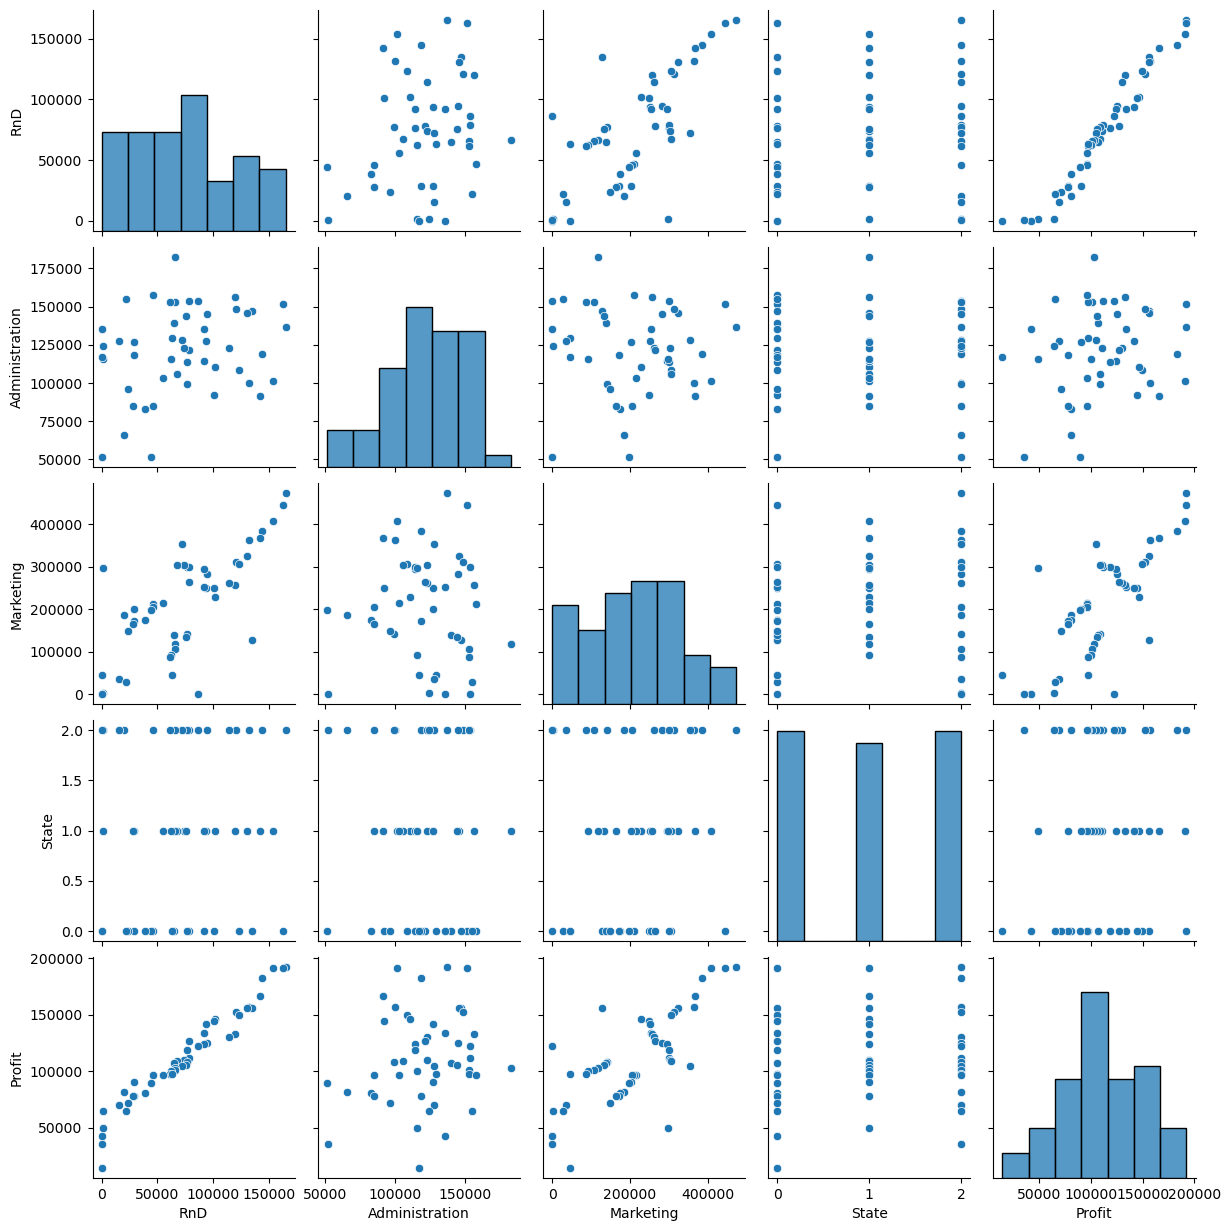

In [11]:
# Show pair plots of the dataset
sns.pairplot(df)

### Split the data

In [14]:
# Split the data into x and y
x = df.drop(['Profit', 'State', 'Administration'], axis = 1)
y = df['Profit']

In [15]:
# Split data into Train and test set
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 42)

### Train the model

In [17]:
from sklearn.linear_model import LinearRegression

# Create a model
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the model

In [19]:
# Evaluation of model on traning dataset

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# Predict the y vaules from test dataset
y_pred = model.predict(x_train)

# Calculate all the metrices
mae = mean_absolute_error(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = root_mean_squared_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

# Print all the metrics
print(f"Mean absolute error: {mae:.2f}")
print(f"Mean absolute percentage error: {mape:.2f}%")
print(f"Mean Squared error: {mse:.2f}")
print(f"Root Mean squared error: {rmse:.2f}")
print(f"r2 Score: {r2:.2f}")

Mean absolute error: 6675.94
Mean absolute percentage error: 0.12%
Mean Squared error: 86365150.08
Root Mean squared error: 9293.29
r2 Score: 0.95


In [18]:
# Evaluation of model on testing dataaset

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

# Predict the y vaules from test dataset
y_pred = model.predict(x_test)

# Calculate all the metrices
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print all the metrics
print(f"Mean absolute error: {mae:.2f}")
print(f"Mean absolute percentage error: {mape:.2f}%")
print(f"Mean Squared error: {mse:.2f}")
print(f"Root Mean squared error: {rmse:.2f}")
print(f"r2 Score: {r2:.2f}")

Mean absolute error: 6449.24
Mean absolute percentage error: 0.07%
Mean Squared error: 66537675.85
Root Mean squared error: 8157.06
r2 Score: 0.95


### Model interpretation

In [20]:
model.intercept_

np.float64(45517.06073621356)

In [21]:
model.coef_

array([0.77738669, 0.03888357])

In [22]:
# Model formula
# y = 0.77738669 * RnD + 0.03888357 * Marketing + 45517.06073621356

### Model inference